2026-02-22 15:09:19.740776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771772959.904791      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771772959.952957      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771772960.329460      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771772960.329501      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771772960.329503      24 computation_placer.cc:177] computation placer alr

✅ Mixed precision policy: mixed_float16
   (ViT-B/16 spec strictly maintained — no architectural changes)

GPU CONFIGURATION CHECK
✅ GPU Available: 2 device(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✅ Memory growth enabled

TensorFlow version : 2.19.0
Keras version      : 3.10.0

🎲 Global seed set to : 42

Configuration:
  Batch Size     : 32  (32 to prevent OOM; architecture unchanged)
  Epochs         : 30
  Image Size     : (250, 250)
  Num Classes    : 4  → BG | Healthy | WSSV | WSSV_BG
  Learning Rate  : 0.0001
  Case           : Case2_Aug_Aug_Aug

  Train dir      : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/train
  Validation dir : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/validation
  Test dir       : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/test

DATA PREPARATION
Found 70

/tmp/ipykernel_24/483952735.py:345: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
I0000 00:00:1771772985.407612      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771772985.413436      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_InceptionV3_ViT_B16_Ensemble"

...


📐 Total parameters     : 114,217,060
📐 Trainable parameters : 90,152,708
"dot" with args ['-Tpng', '/tmp/tmpvdnd34kq/tmp6q_b3ky9'] returned code: -6

stdout, stderr:
 b''
b"newtrap: Trapezoid-table overflow 441\ndot: trapezoid.c:84: newtrap: Assertion `0' failed.\n"

⚠️  Could not save diagram: "dot" with args ['-Tpng', '/tmp/tmpvdnd34kq/tmp6q_b3ky9'] returned code: -6

🚀 PHASE 1: Training with frozen MobileNetV2 & InceptionV3 backbones


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1771773037.189280      88 service.cc:152] XLA service 0x78ed04002460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771773037.189317      88 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771773037.189321      88 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771773047.438865      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771773110.303243      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.3564 - loss: 1.5039
Epoch 1: val_accuracy improved from -inf to 0.58867, saving model to MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_phase1_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.3567 - loss: 1.5032 - val_accuracy: 0.5887 - val_loss: 0.9307 - learning_rate: 1.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.5199 - loss: 1.1254
Epoch 2: val_accuracy improved from 0.58867 to 0.69600, saving model to MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_phase1_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 128s 581ms/step - accuracy: 0.5200 - loss: 1.1251 - val_accuracy: 0.6960 - val_loss: 0.7194 - learning_rate: 1.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.5884 - loss: 0.9685
Epoch 3: val_accuracy improved from 0.69600 to 0.73600, saving model to MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_phase1_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 128s 5

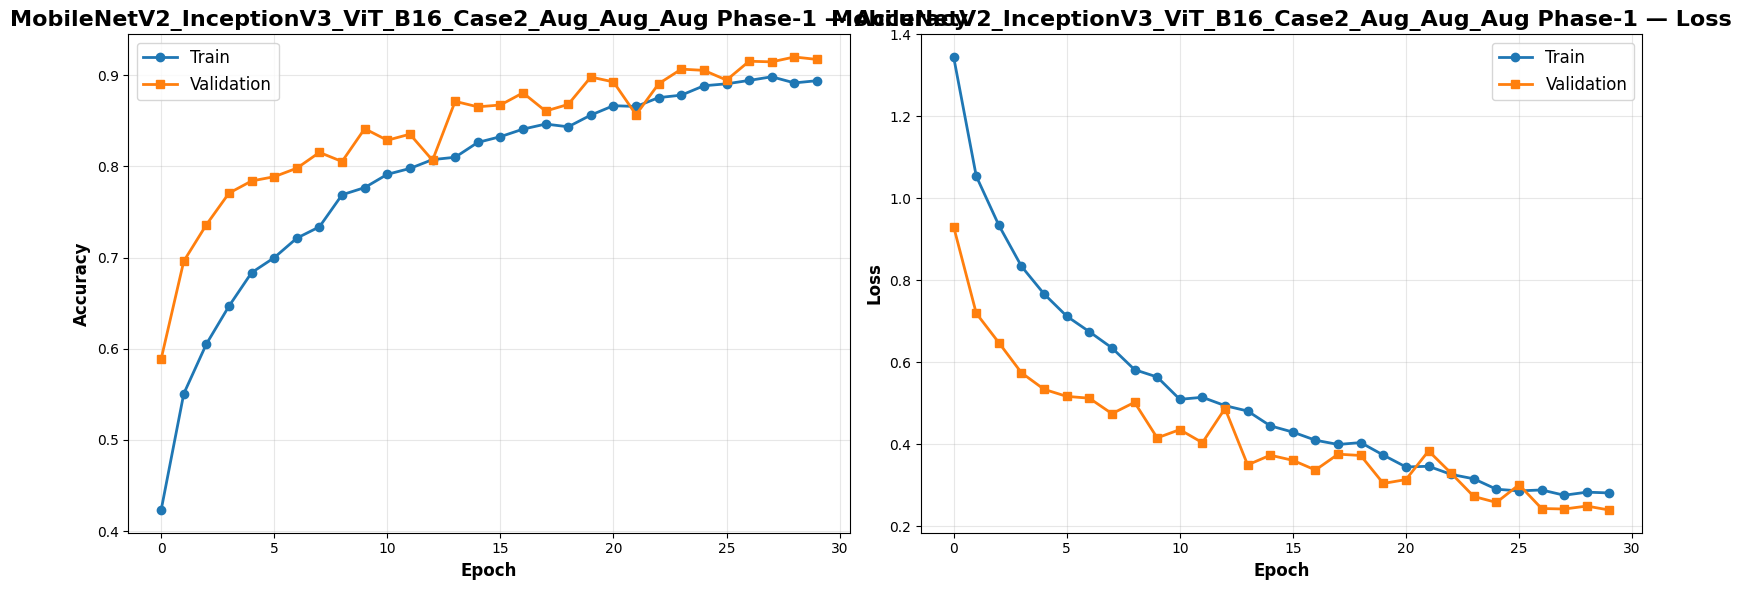


🔧 PHASE 2: Fine-tuning top layers of MobileNetV2 & InceptionV3
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.7713 - loss: 0.6745
Epoch 1: val_accuracy improved from -inf to 0.88733, saving model to MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_phase2_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7714 - loss: 0.6742 - val_accuracy: 0.8873 - val_loss: 0.3211 - learning_rate: 1.0000e-05
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.8273 - loss: 0.4682
Epoch 2: val_accuracy improved from 0.88733 to 0.89800, saving model to MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_phase2_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 128s 580ms/step - accuracy: 0.8274 - loss: 0.4681 - val_accuracy: 0.8980 - val_loss: 0.2832 - learning_rate: 1.0000e-05
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8547 - loss: 0.3852
Epoch 3: val_accuracy improved from 0.89800 to 0.90667, saving model to MobileNetV2_InceptionV3_ViT_

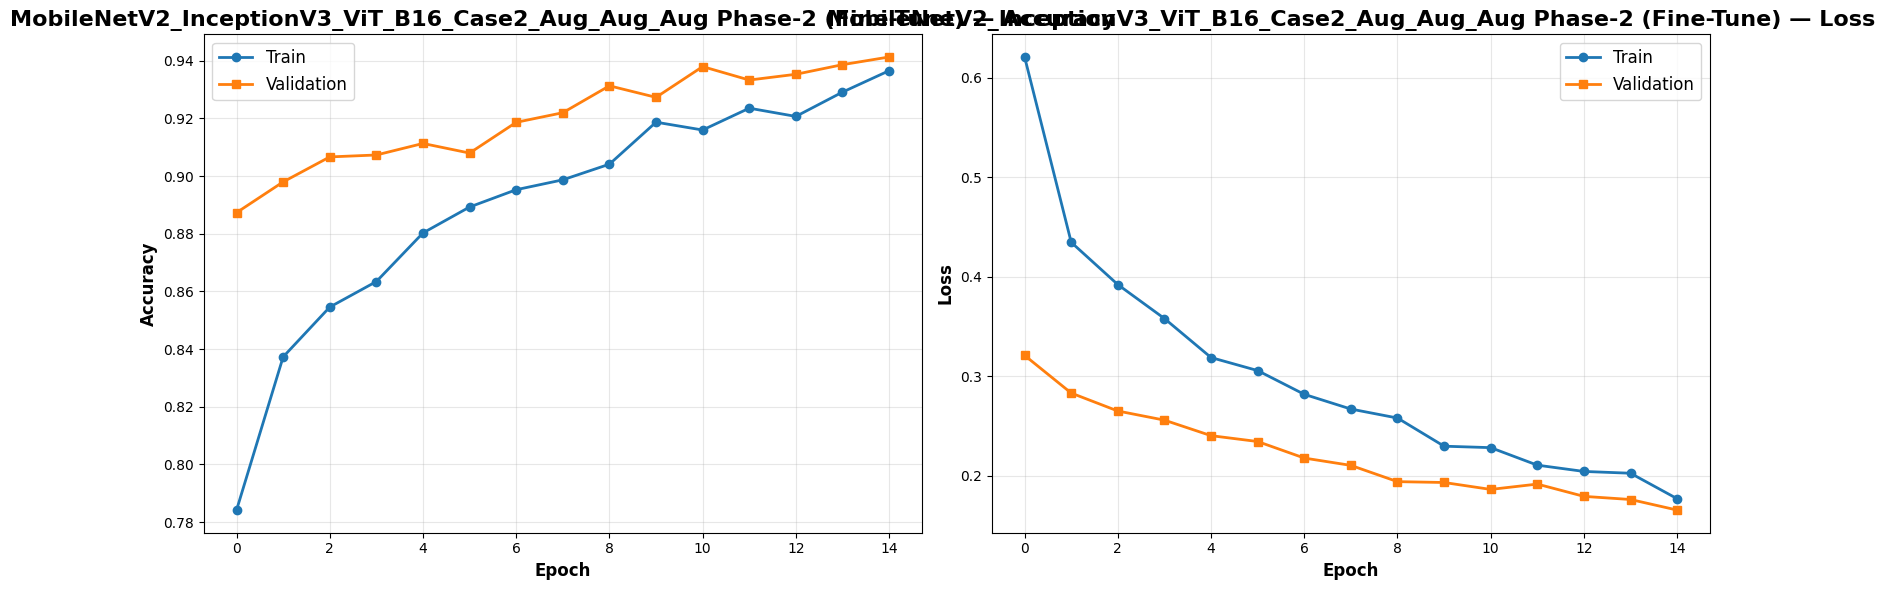

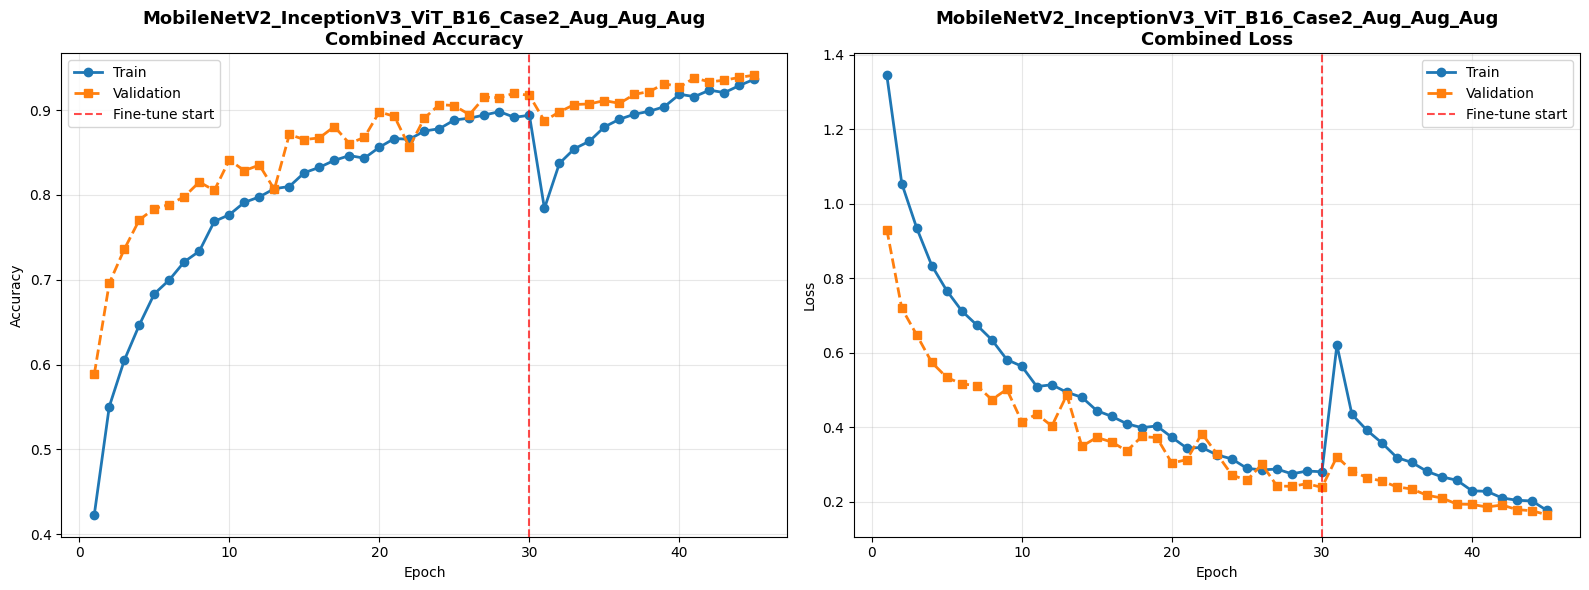


EVALUATION RESULTS ON TEST DATA — MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug

🔍 Generating predictions on test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 54s 656ms/step

📊 CLASSIFICATION PERFORMANCE METRICS (TEST SET):
                 Class  Precision   Recall  F1-Score  Support
                    BG   0.932292 0.954667  0.943347      375
               Healthy   0.956640 0.941333  0.948925      375
                  WSSV   0.936675 0.946667  0.941645      375
               WSSV_BG   0.951087 0.933333  0.942127      375
Overall (Weighted Avg)   0.944173 0.944000  0.944011     1500

🎯 Test Accuracy : 0.9440 (94.40%)

DETAILED CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

          BG     0.9323    0.9547    0.9433       375
     Healthy     0.9566    0.9413    0.9489       375
        WSSV     0.9367    0.9467    0.9416       375
     WSSV_BG     0.9511    0.9333    0.9421       375

    accuracy                         0.9440      1500
   mac

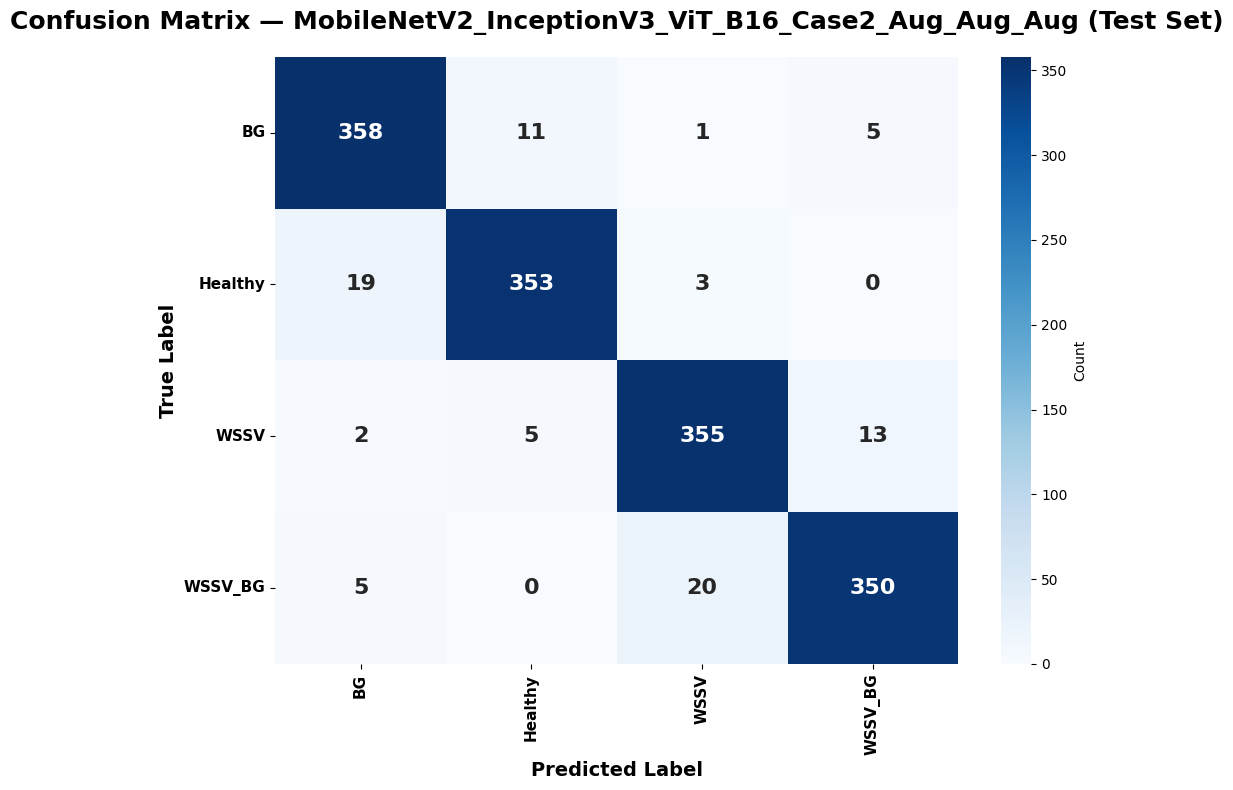


🎉 FINAL SUMMARY — MobileNetV2 + InceptionV3 + ViT-B/16 Triple Ensemble
  Case             : Case2_Aug_Aug_Aug
  ViT-B/16 spec   : proj=768 | heads=12 | mlp=3072 | blocks=12
  Total Train Time : 1h 40m 52s
  Test Accuracy    : 94.40%
  Precision (W)    : 94.42%
  Recall (W)       : 94.40%
  F1-Score (W)     : 94.40%
📊 Results saved : MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_results.csv
💾 Model saved   : MobileNetV2_InceptionV3_ViT_B16_Case2_Aug_Aug_Aug_final.keras


In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   CNN-ViT HYBRID ENSEMBLE MODEL 3: MobileNetV2 + InceptionV3 + ViT-B/16   ║
║         Shrimp Disease Classification | Kaggle T4 GPU Optimized             ║
║                                                                              ║
║  ViT-B/16 STRICT SPEC:                                                       ║
║    projection_dim = 768  |  num_heads = 12                                  ║
║    mlp_dim = 3072        |  num_blocks = 12                                 ║
║                                                                              ║
║  OOM resolved via:  mixed_float16  +  batch_size=32                        ║
║  Architecture unchanged from ViT-B/16 paper specification                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET CASES — uncomment exactly ONE block:
  Case 1 → Raw/train  | Raw/val  | Raw/test        (Orig | Orig | Orig)
  Case 2 → Aug/train  | Aug/val  | Aug/test        (Aug  | Aug  | Aug )
  Case 3 → Raw/train  | Raw/val  | Aug/test        (Orig | Orig | Aug )

Classes: BG | Healthy | WSSV | WSSV_BG  (NUM_CLASSES = 4)
"""

import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

# ============================================================
# MIXED PRECISION — ONLY memory fix used; ViT-B/16 is untouched
# ============================================================
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision policy: mixed_float16")
print("   (ViT-B/16 spec strictly maintained — no architectural changes)")

# ============================================================
# CASE SELECTION — uncomment exactly ONE block
# ============================================================

# ── CASE 1: Original | Original | Original ──────────────────
# RAW            = '/kaggle/input/elsevier-disease-shrimp-data/Raw_Train_test_Validation'
# train_dir      = os.path.join(RAW, 'train')
# validation_dir = os.path.join(RAW, 'validation')
# test_dir       = os.path.join(RAW, 'test')
# CASE_NAME      = 'Case1_Orig_Orig_Orig'

# ── CASE 2: Augmented | Augmented | Augmented ───────────────
AUG            = '/kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs'
train_dir      = os.path.join(AUG, 'train')
validation_dir = os.path.join(AUG, 'validation')
test_dir       = os.path.join(AUG, 'test')
CASE_NAME      = 'Case2_Aug_Aug_Aug'

# ── CASE 3: Original | Original | Augmented ─────────────────
# RAW            = '/kaggle/input/elsevier-disease-shrimp-data/Raw_Train_test_Validation'
# AUG            = '/kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs'
# train_dir      = os.path.join(RAW, 'train')
# validation_dir = os.path.join(RAW, 'validation')
# test_dir       = os.path.join(AUG, 'test')
# CASE_NAME      = 'Case3_Orig_Orig_Aug'

# ============================================================
# GPU CONFIGURATION
# ============================================================
print("\n" + "=" * 80)
print("GPU CONFIGURATION CHECK")
print("=" * 80)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Memory growth enabled")
else:
    print("⚠️  No GPU detected! Running on CPU")
print(f"\nTensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
SEED          = 42
BATCH_SIZE    = 32
EPOCHS        = 30
IMG_SIZE      = (250, 250)
NUM_CLASSES   = 4
LEARNING_RATE = 0.0001
MODEL_NAME    = f'MobileNetV2_InceptionV3_ViT_B16_{CASE_NAME}'

random.seed(SEED);  np.random.seed(SEED);  tf.random.set_seed(SEED)

print(f"\n🎲 Global seed set to : {SEED}")
print(f"\nConfiguration:")
print(f"  Batch Size     : {BATCH_SIZE}  (32 to prevent OOM; architecture unchanged)")
print(f"  Epochs         : {EPOCHS}")
print(f"  Image Size     : {IMG_SIZE}")
print(f"  Num Classes    : {NUM_CLASSES}  → BG | Healthy | WSSV | WSSV_BG")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Case           : {CASE_NAME}")
print(f"\n  Train dir      : {train_dir}")
print(f"  Validation dir : {validation_dir}")
print(f"  Test dir       : {test_dir}")

# ============================================================
# DATA PREPARATION
# ============================================================
print("\n" + "=" * 80)
print("DATA PREPARATION")
print("=" * 80)

train_datagen    = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    validation_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f"\n✓ Data generators created")
print(f"  Training samples   : {train_generator.samples}")
print(f"  Validation samples : {val_generator.samples}")
print(f"  Test samples       : {test_generator.samples}")
print(f"  Classes            : {class_names}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def format_time(seconds):
    h, rem = divmod(int(seconds), 3600)
    m, s   = divmod(rem, 60)
    if h: return f"{h}h {m}m {s}s"
    if m: return f"{m}m {s}s"
    return f"{s}s"


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].plot(history.history['accuracy'],     lw=2, label='Train',      marker='o')
    axes[0].plot(history.history['val_accuracy'], lw=2, label='Validation', marker='s')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     lw=2, label='Train',      marker='o')
    axes[1].plot(history.history['val_loss'], lw=2, label='Validation', marker='s')
    axes[1].set_title(f'{model_name} — Loss', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def evaluate_model(model, test_gen, model_name):
    print(f"\n{'=' * 80}")
    print(f"EVALUATION RESULTS ON TEST DATA — {model_name}")
    print("=" * 80)
    test_gen.reset()
    print("\n🔍 Generating predictions on test set...")
    predictions = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes
    cn     = list(test_gen.class_indices.keys())

    accuracy = np.mean(y_pred == y_true)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(NUM_CLASSES))

    metrics_df = pd.DataFrame({
        'Class': cn, 'Precision': precision,
        'Recall': recall, 'F1-Score': f1, 'Support': support
    })
    wp, wr, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    overall = pd.DataFrame({
        'Class': ['Overall (Weighted Avg)'], 'Precision': [wp],
        'Recall': [wr], 'F1-Score': [wf1], 'Support': [len(y_true)]
    })
    metrics_df = pd.concat([metrics_df, overall], ignore_index=True)

    print("\n📊 CLASSIFICATION PERFORMANCE METRICS (TEST SET):")
    print("=" * 80)
    print(metrics_df.to_string(index=False))
    print("=" * 80)
    print(f"\n🎯 Test Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print("\n" + "=" * 80)
    print("DETAILED CLASSIFICATION REPORT (TEST SET)")
    print("=" * 80)
    print(classification_report(y_true, y_pred, target_names=cn, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cn, yticklabels=cn,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 16, 'weight': 'bold'})
    plt.title(f'Confusion Matrix — {model_name} (Test Set)',
              fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label',      fontsize=14, fontweight='bold')
    plt.xticks(fontsize=11, fontweight='bold', rotation=90)
    plt.yticks(fontsize=11, fontweight='bold', rotation=0)
    plt.tight_layout(); plt.show()
    return accuracy, wp, wr, wf1


def plot_combined_history(h1, h2, model_name, phase1_len):
    keys   = ('accuracy', 'val_accuracy', 'loss', 'val_loss')
    merged = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in keys}
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    e = range(1, len(merged['accuracy']) + 1)
    axes[0].plot(e, merged['accuracy'],     'o-',  lw=2, label='Train')
    axes[0].plot(e, merged['val_accuracy'], 's--', lw=2, label='Validation')
    axes[0].axvline(x=phase1_len, color='red', ls='--', alpha=0.7, label='Fine-tune start')
    axes[0].set_title(f'{model_name}\nCombined Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(e, merged['loss'],     'o-',  lw=2, label='Train')
    axes[1].plot(e, merged['val_loss'], 's--', lw=2, label='Validation')
    axes[1].axvline(x=phase1_len, color='red', ls='--', alpha=0.7, label='Fine-tune start')
    axes[1].set_title(f'{model_name}\nCombined Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{MODEL_NAME}_combined_history.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# PatchPositionEmbedding — XLA / gradient-safe
# ============================================================
class PatchPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_embedding',
            shape=(1, self.num_patches, self.projection_dim),
            initializer='random_normal', trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches,
                    'projection_dim': self.projection_dim})
        return cfg


# ============================================================
# ViT-B/16 — STRICT PAPER SPECIFICATION
#   projection_dim=768 | num_heads=12 | mlp_dim=3072 | num_blocks=12
# ============================================================
def create_vit_b16(input_shape,
                   projection_dim=768,
                   num_heads=12,
                   mlp_dim=3072,
                   num_blocks=12,
                   dropout=0.1,
                   name='ViT_B16'):
    patch_size  = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    inputs = layers.Input(shape=input_shape, name=f'{name}_input')

    patches = layers.Conv2D(
        projection_dim, kernel_size=patch_size, strides=patch_size,
        padding='valid', name=f'{name}_patch_conv'
    )(inputs)
    patches = layers.Reshape(
        (num_patches, projection_dim), name=f'{name}_patch_reshape'
    )(patches)

    x = PatchPositionEmbedding(
        num_patches, projection_dim, name=f'{name}_pos_emb'
    )(patches)

    for i in range(num_blocks):
        x1   = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln1_{i}')(x)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=dropout,
            name=f'{name}_mha_{i}'
        )(x1, x1)
        x2   = layers.Add(name=f'{name}_add1_{i}')([attn, x])
        x3   = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln2_{i}')(x2)
        x3   = layers.Dense(mlp_dim, activation='gelu',
                            name=f'{name}_mlp_fc1_{i}')(x3)
        x3   = layers.Dropout(dropout, name=f'{name}_mlp_drop1_{i}')(x3)
        x3   = layers.Dense(projection_dim,
                            name=f'{name}_mlp_fc2_{i}')(x3)
        x3   = layers.Dropout(dropout, name=f'{name}_mlp_drop2_{i}')(x3)
        x    = layers.Add(name=f'{name}_add2_{i}')([x3, x2])

    x = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln_final')(x)
    x = layers.GlobalAveragePooling1D(name=f'{name}_gap')(x)
    return Model(inputs=inputs, outputs=x, name=name)


# ============================================================
# ENSEMBLE: MobileNetV2 + InceptionV3 (CNN frontends) + ViT-B/16 (backend)
#
# MobileNetV2  → GAP → 1280-d ─┐
# InceptionV3  → GAP → 2048-d ─┼→ each projected to 512-d
# ViT-B/16     → GAP →  768-d ─┘
# Concatenate  →       1536-d → Dense head → 4-class Softmax
#
# Branch projection (512-d each) keeps the fusion dimension
# manageable for the T4 GPU while preserving all feature information.
# ============================================================
def build_triple_ensemble(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape, name='input')

    # ── CNN Frontend A: MobileNetV2 (ImageNet, frozen phase-1) ──
    mobilenet = MobileNetV2(
        include_top=False, weights='imagenet',
        input_shape=input_shape, pooling='avg'
    )
    mobilenet.trainable = False
    mobile_out = mobilenet(inputs, training=False)         # (batch, 1280)

    # ── CNN Frontend B: InceptionV3 (ImageNet, frozen phase-1) ──
    inception = InceptionV3(
        include_top=False, weights='imagenet',
        input_shape=input_shape, pooling='avg'
    )
    inception.trainable = False
    inception_out = inception(inputs, training=False)      # (batch, 2048)

    # ── Transformer Backend: ViT-B/16 (trained from scratch) ─────
    vit     = create_vit_b16(input_shape, name='ViT_B16')
    vit_out = vit(inputs)                                  # (batch, 768)

    # ── Branch Projections (normalise dims before fusion) ─────────
    mobile_proj    = layers.Dense(512, activation='relu',
                                  name='mobile_proj')(mobile_out)
    inception_proj = layers.Dense(512, activation='relu',
                                  name='inception_proj')(inception_out)
    vit_proj       = layers.Dense(512, activation='relu',
                                  name='vit_proj')(vit_out)

    # ── Feature Fusion → 1536-d ───────────────────────────────────
    fused = layers.Concatenate(name='feature_fusion')(
        [mobile_proj, inception_proj, vit_proj]
    )

    # ── Classification Head ───────────────────────────────────────
    x = layers.Dense(1024, name='fc1')(fused)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)

    x = layers.Dense(512, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.4, name='drop2')(x)

    x = layers.Dense(256, name='fc3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.Dropout(0.3, name='drop3')(x)

    # dtype=float32 required when using mixed_float16
    outputs = layers.Dense(
        num_classes, activation='softmax',
        dtype='float32', name='output'
    )(x)

    return (Model(inputs=inputs, outputs=outputs,
                  name='MobileNetV2_InceptionV3_ViT_B16_Ensemble'),
            mobilenet, inception)


# ============================================================
# BUILD MODEL
# ============================================================
print("\n" + "=" * 80)
print("BUILDING MODEL: MobileNetV2 + InceptionV3 (CNNs) + ViT-B/16 (Triple Ensemble)")
print("ViT-B/16 spec: projection_dim=768 | num_heads=12 | mlp_dim=3072 | num_blocks=12")
print("=" * 80)

input_shape = IMG_SIZE + (3,)
model, mobilenet_base, inception_base = build_triple_ensemble(input_shape, NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n📐 Total parameters     : {total_params:,}")
print(f"📐 Trainable parameters : {trainable_params:,}")

try:
    tf.keras.utils.plot_model(
        model, to_file=f'{MODEL_NAME}_architecture.png',
        show_shapes=True, show_layer_names=True,
        dpi=96, expand_nested=False
    )
    print(f"✅ Architecture diagram saved: {MODEL_NAME}_architecture.png")
except Exception as e:
    print(f"⚠️  Could not save diagram: {e}")

# ============================================================
# PHASE 1 — Frozen CNN backbones, train ViT-B/16 + head
# ============================================================
print("\n" + "=" * 80)
print("🚀 PHASE 1: Training with frozen MobileNetV2 & InceptionV3 backbones")
print("=" * 80)

callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1, min_delta=0.001
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{MODEL_NAME}_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

start_p1   = time.time()
history_p1 = model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_p1, verbose=1
)
phase1_time = time.time() - start_p1
print(f"\n✅ Phase 1 complete — {format_time(phase1_time)}")
plot_training_history(history_p1, f'{MODEL_NAME} Phase-1')

# ============================================================
# PHASE 2 — Fine-tune top layers of both CNN backbones
# ============================================================
print("\n" + "=" * 80)
print("🔧 PHASE 2: Fine-tuning top layers of MobileNetV2 & InceptionV3")
print("=" * 80)

mobilenet_base.trainable = True
MOBILE_FT = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:MOBILE_FT]:
    layer.trainable = False
for layer in mobilenet_base.layers[MOBILE_FT:]:
    layer.trainable = True

inception_base.trainable = True
INCEPTION_FT = len(inception_base.layers) - 50
for layer in inception_base.layers[:INCEPTION_FT]:
    layer.trainable = False
for layer in inception_base.layers[INCEPTION_FT:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-8, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{MODEL_NAME}_phase2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

start_p2   = time.time()
history_p2 = model.fit(
    train_generator, epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_p2, verbose=1
)
phase2_time = time.time() - start_p2
print(f"\n✅ Phase 2 complete — {format_time(phase2_time)}")
plot_training_history(history_p2, f'{MODEL_NAME} Phase-2 (Fine-Tune)')

plot_combined_history(history_p1, history_p2, MODEL_NAME,
                      len(history_p1.history['accuracy']))

# ============================================================
# EVALUATION
# ============================================================
total_time = phase1_time + phase2_time
acc, prec, rec, f1 = evaluate_model(model, test_generator, MODEL_NAME)

# ============================================================
# FINAL SUMMARY & SAVE
# ============================================================
print("\n" + "=" * 80)
print("🎉 FINAL SUMMARY — MobileNetV2 + InceptionV3 + ViT-B/16 Triple Ensemble")
print("=" * 80)
print(f"  Case             : {CASE_NAME}")
print(f"  ViT-B/16 spec   : proj=768 | heads=12 | mlp=3072 | blocks=12")
print(f"  Total Train Time : {format_time(total_time)}")
print(f"  Test Accuracy    : {acc * 100:.2f}%")
print(f"  Precision (W)    : {prec * 100:.2f}%")
print(f"  Recall (W)       : {rec * 100:.2f}%")
print(f"  F1-Score (W)     : {f1 * 100:.2f}%")
print("=" * 80)

results = pd.DataFrame([{
    'Model': MODEL_NAME, 'Case': CASE_NAME,
    'ViT_spec': 'proj=768,heads=12,mlp=3072,blocks=12',
    'Test Accuracy': acc, 'Precision': prec,
    'Recall': rec, 'F1-Score': f1,
    'Training Time': format_time(total_time)
}])
results.to_csv(f'{MODEL_NAME}_results.csv', index=False)
print(f"📊 Results saved : {MODEL_NAME}_results.csv")

model.save(f'{MODEL_NAME}_final.keras')
print(f"💾 Model saved   : {MODEL_NAME}_final.keras")